In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

In [3]:
import matplotlib.pyplot as plt

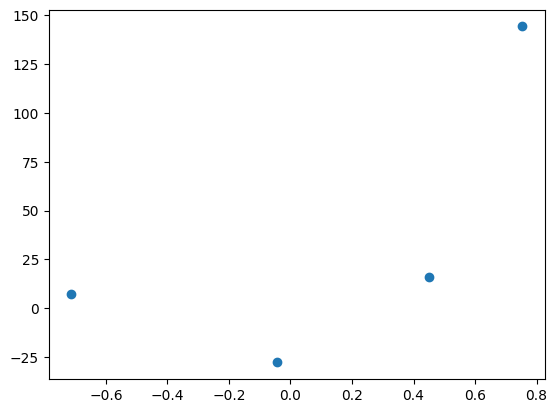

In [4]:
plt.scatter(X,y)

In [5]:
#lets apply ols
from sklearn.linear_model import LinearRegression


In [6]:
reg=LinearRegression()
reg.fit(X,y)

LinearRegression()

In [7]:
reg.coef_

array([78.35063668])

In [8]:
reg.intercept_

np.float64(26.15963284313262)

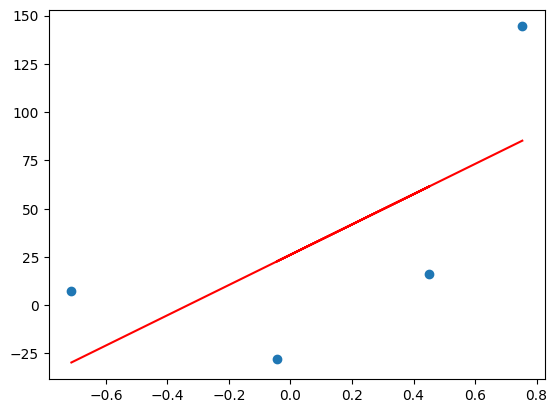

In [10]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

GD

In [11]:
#lets apply gd assuming slope is constant m=78.35
# and lets assume the starting value for intercept b=0
y_pred=((78.35*X)+0).reshape(4)

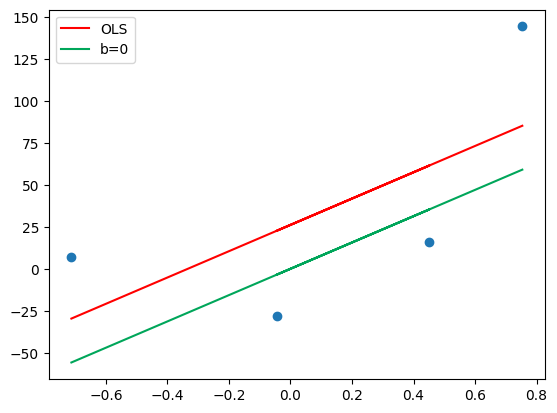

In [12]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b=0')
plt.legend()
plt.show()

In [14]:
m=78.35
b=0

loss_slope=-2* np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [15]:
#learning rate=0.1
lr=0.1
step_size=loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [16]:
#calculating new intercept
b=b-step_size
b

np.float64(20.927763408209216)

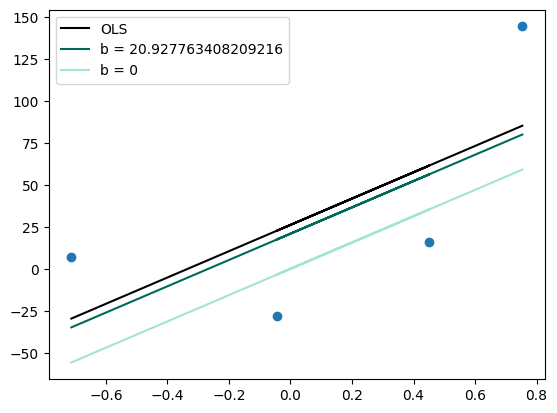

In [17]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='black', label='OLS')
plt.plot(X, y_pred1, color='#006a5a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()

plt.show()

In [18]:
#iteration 2
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [19]:
step_size=loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [20]:
b=b-step_size
b

np.float64(25.11331608985106)

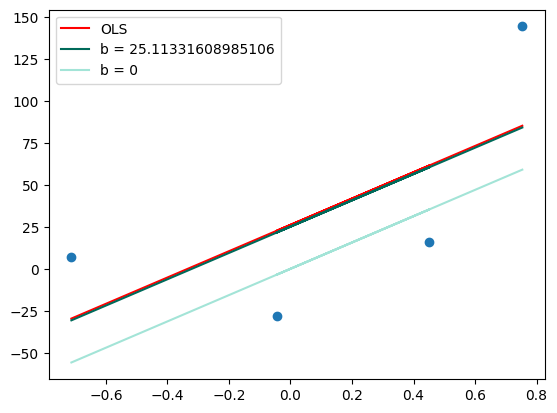

In [22]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#006a5a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()

plt.show()

In [23]:
#iteration 3
#iteration 2
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-8.371105363283675)

In [24]:
step_size=loss_slope*lr
step_size

np.float64(-0.8371105363283675)

In [25]:
b=b-step_size
b

np.float64(25.95042662617943)

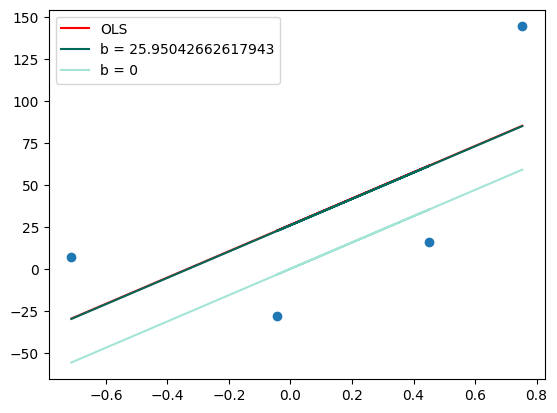

In [26]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#006a5a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()

plt.show()

Creating our own GD class

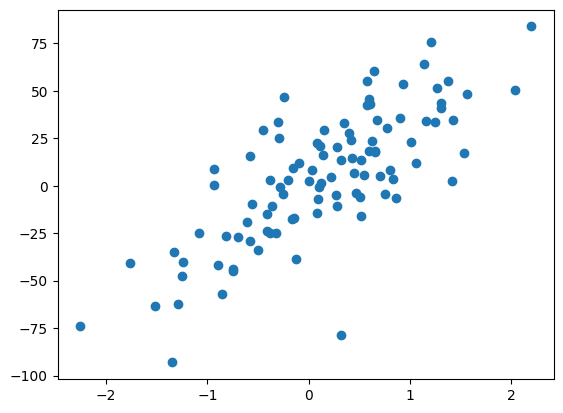

In [27]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

plt.scatter(X, y)

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [29]:

from sklearn.linear_model import LinearRegression

In [30]:

lr = LinearRegression()

In [31]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[30.49533699]
-0.9293617500640821


In [32]:

y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.5693994821338065

In [34]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b

In [35]:
gd = GDRegressor(0.001,50)

In [36]:

gd.fit(X_train,y_train)

30.706116411852253 -1.0451532153276042


In [37]:

y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.5693992463798886